## Notebook 3: Principal Component Analysis (PCA):

This notebook is the third step in our analysis pipeline, focusing on unsupervised machine learning. We will use the fully preprocessed data from Notebook 1 to perform Principal Component Analysis (PCA) to visualise the main sources of variation in the data.

---
### Data Source

The primary input for this notebook is the fully cleaned, normalised, and scaled data that was generated and exported at the end of the first notebook (`01_RNA_Seq_Preprocessing_and_QC.ipynb`).

* **Input File**: `preprocessed_rna_seq_data.tsv` (or the `df_scaled` variable)
* **Description**: The data contains scaled expression values for ~17,000 genes across all 2,913 aligned samples, ready for PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# For PCA 
from sklearn.decomposition import PCA

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Loading the Preprocessed Expression Data

We load the normalised and transformed gene expression dataset.  

This dataset has already undergone preprocessing steps such as filtering, normalisation, transformation ( log2(x+1) ), transposition and scaling (Standard Scaling), and is ready for dimensionality reduction. 

Please make sure your dataset in use has undergone the same steps.

Each row represents a sample, and each column corresponds to a gene.  
We display the shape and a brief preview to confirm that the data has loaded correctly.

In [2]:
# Load the data
df_scaled = pd.read_csv("preprocessed_rna_seq_data.tsv", sep='\t', index_col=0)

In [3]:
# Display the shape and a preview to confirm it's loaded correctly
print(f"Loaded df_scaled DataFrame shape: {df_scaled.shape}")
print("\nPreview of the loaded data:")
print(df_scaled.head(1))

Loaded df_scaled DataFrame shape: (3207, 16374)

Preview of the loaded data:
             A1BG      A2M     A2ML1    A4GALT      AAAS     AACS     AADAC  \
S000001  0.696056 -0.05582 -0.405865  2.072324  0.110659  0.62985 -0.601306   

           AADAT     AAED1    AAGAB  ...    ZWILCH     ZWINT    ZXDA  \
S000001  0.00009  0.416643  0.37392  ... -0.088904 -1.257953  0.0537   

             ZXDB      ZXDC    ZYG11A    ZYG11B       ZYX     ZZEF1      ZZZ3  
S000001  0.339879 -1.203003 -0.981304  0.522207  0.012783  0.105367 -0.711122  

[1 rows x 16374 columns]


### Loading Sample Metadata

Here, we load the clinical metadata associated with our 3,207 samples. This file contains information for each patient, such as the PAM50 cancer subtype and hormone receptor status.

We load this at the beginning of our workflow to have it ready for downstream analysis. It will be essential for adding context to our visualizations and for defining sample groups for analysis.

In [4]:
metadata = pd.read_csv("GSE202203_clean_metadata_final.csv", index_col=0)

print("Metadata loaded successfully.")

Metadata loaded successfully.


### Initialising PCA on all components and determining the Number of Principal Components to Retain

To decide how many principal components to keep for downstream analysis, we fit PCA across all components and calculate the cumulative explained variance.

We then identified how many components are required to capture key thresholds of total variance (50%, 70%, and 80%).

A scree plot is shown to visualise how variance accumulates across components. This helps justify the number of components retained in the final PCA model.

In [5]:
# Run PCA on all components to create the pca_all object
pca_all = PCA()
pca_all.fit(df_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


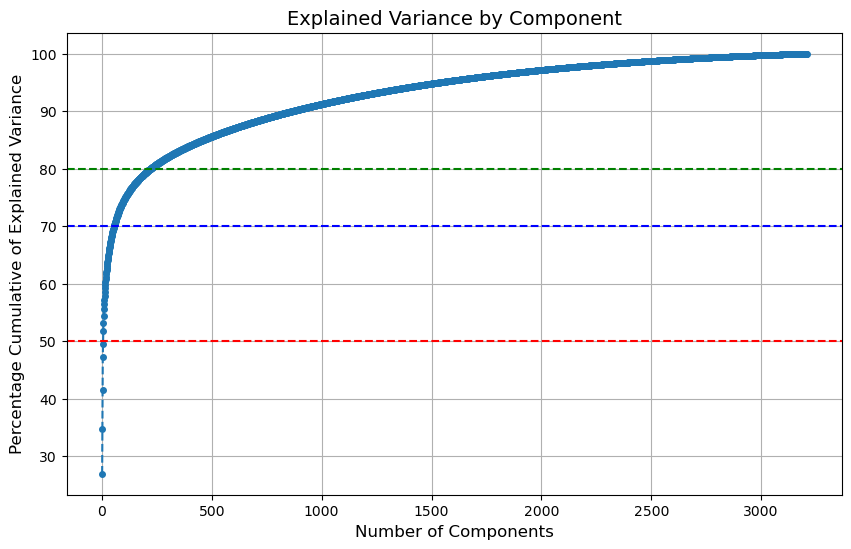

Number of components to explain 50% of variance: 6
Number of components to explain 70% of variance: 55
Number of components to explain 80% of variance: 222


In [6]:
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)

# Find the number of components needed for 50% and 70% variance
components_50_percent = np.where(cumulative_variance >= 0.50)[0][0] + 1
components_70_percent = np.where(cumulative_variance >= 0.70)[0][0] + 1
components_80_percent = np.where(cumulative_variance >= 0.80)[0][0] + 1

plt.figure(figsize=(10, 6))

# Plot the percentage of cumulative explained variance
plt.plot(np.arange(1, len(cumulative_variance) + 1),
         cumulative_variance * 100,
         marker='o', markersize=4, linestyle='--')

plt.title('Explained Variance by Component', fontsize=14)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Percentage Cumulative of Explained Variance', fontsize=12)

# Add horizontal lines for the 50% and 70% thresholds
plt.axhline(y=50, color='r', linestyle='--', label='50% Threshold')
plt.axhline(y=70, color='b', linestyle='--', label='70% Threshold')
plt.axhline(y=80, color='g', linestyle='--', label='80% Threshold')

plt.grid(True)
plt.show()

print(f"Number of components to explain 50% of variance: {components_50_percent}")
print(f"Number of components to explain 70% of variance: {components_70_percent}")
print(f"Number of components to explain 80% of variance: {components_80_percent}")


### Extracting a total of 55 Principal Components, because they explain atleast 70% of the data.

In [7]:
# Initialising PCA with the chosen number of components
pca = PCA(n_components=55)

# Fit the PCA model to the scaled data and transform it
principal_components = pca.fit_transform(df_scaled)

# Create a new DataFrame from the principal components
pc_columns = [f'PC{i+1}' for i in range(55)]
pca_df_55 = pd.DataFrame(data=principal_components,
                         columns=pc_columns,
                         index=df_scaled.index)

print("Final PCA DataFrame shape:", pca_df_55.shape)
print("\nFirst row of the PCA DataFrame:")
print(pca_df_55.head(1))

Final PCA DataFrame shape: (3207, 55)

First row of the PCA DataFrame:
              PC1       PC2        PC3        PC4        PC5        PC6  \
S000001 -4.576367 -1.688892 -25.866072 -16.660906 -16.546349  21.166695   

               PC7        PC8        PC9       PC10  ...      PC46      PC47  \
S000001 -35.097138 -15.531224 -11.417674  20.320767  ...  7.155525 -6.575413   

             PC48      PC49      PC50      PC51      PC52     PC53      PC54  \
S000001 -3.337588 -8.363336  2.603167 -2.174088  1.087265 -3.67837  4.393918   

             PC55  
S000001 -4.721523  

[1 rows x 55 columns]


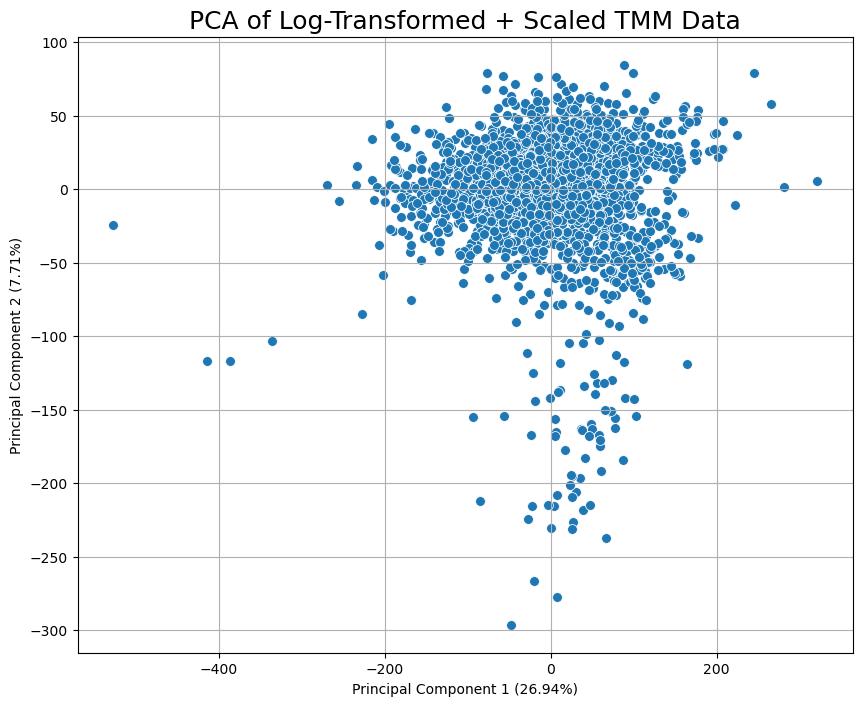

In [8]:
# pca_df_55 is the DataFrame with 55 principal components

# Get the explained variance ratios from the 'pca' object
explained_variance_pc1 = pca.explained_variance_ratio_[0] * 100
explained_variance_pc2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1',
                y='PC2',
                data=pca_df_55,
                s=50)

plt.title('PCA of Log-Transformed + Scaled TMM Data', fontsize=18)

plt.xlabel(f'Principal Component 1 ({explained_variance_pc1:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_pc2:.2f}%)')
plt.grid(True)
plt.show()

### Visualising the PCA Results

This scatter plot visualises the relationships between all **3,207** tumour samples based on the first two principal components, which capture the largest sources of variation in the data. Each point on the plot represents a single patient sample.

The overall PCA plot seems to have a very dense central core nearly two outer arms with density decreasing as the points spread outwards.There are also several distinct points separating from the central mass. There could be defined subgroups within the data.

---

### Combining PCA Results with Metadata

We have reduced the dimensionality of our data to 55 principal components, next step is to prepare this data for visualisation. To see if the patterns discovered by PCA correspond to known clinical groups, we need to merge our PCA results with the patient metadata.

The following code will align the two DataFrames to ensure they contain the exact same set of samples. This combined DataFrame will then be used to create a scatter plot where each point is coloured by a specific clinical feature.

In [9]:
pca_df_55.shape == metadata.shape

False

### As the number of samples in the metadata and df_scaled data do not match, we filter the pca dataframe and keep only the samples that match.

In [10]:
# Filter pca_df_55 to keep only the samples that are also in the metadata index
pca_df_filtered = pca_df_55.loc[metadata.index]
pca_with_metadata = pca_df_filtered.join(metadata)
print(f"pca with metadata shape: {pca_with_metadata.shape}")
pca_with_metadata.head()

pca with metadata shape: (2913, 78)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,endocrine treated,chemo treated,overall survival days,overall survival years,overall survival event,relapse free interval days,relapse free interval years,relapse free interval event,esr1 expression: log2(tpm+0.1),esr2 expression: log2(tpm+0.1)
Sample ID,,,,,,,,,,,,,,,,,,,,,
S000001,-4.576367,-1.688892,-25.866072,-16.660906,-16.546349,21.166695,-35.097138,-15.531224,-11.417674,20.320767,...,1.0,0.0,3187.0,8.725530,0.0,387.0,1.059548,0.0,8.396473,-3.321928
S000002,-201.999974,-58.616500,13.542202,76.902151,-19.950696,5.573689,-9.552736,-18.613843,11.314110,1.341110,...,0.0,1.0,3192.0,8.739220,0.0,413.0,1.130732,0.0,3.913672,-3.321928
S000003,14.396870,-1.129880,8.368202,-4.559965,-18.976908,2.569538,-5.500560,33.686070,-10.439242,-13.507788,...,0.0,0.0,785.0,2.149213,1.0,719.0,1.968515,0.0,3.226214,-2.581884
S000006,-16.511313,-36.649614,36.132448,59.499586,-13.962385,1.133011,-22.371600,-1.702027,-15.527626,12.193587,...,1.0,1.0,875.0,2.395619,1.0,682.0,1.867214,0.0,0.696891,-2.043983
S000011,-67.510552,-22.711735,-0.006935,0.148497,35.121109,5.996565,8.472041,-4.162225,19.369014,11.463961,...,1.0,0.0,3186.0,8.722793,0.0,435.0,1.190965,0.0,6.407396,-2.498252


### Exporting PCA Results for Clustering

To keep our project modular and organised, we save the final PCA results to a file.

This exported file will serve as the input for our next notebook, `04_Clustering.ipynb`, ensuring that our clustering analysis begins with the correct, dimensionally-reduced data from the PCA. This practice prevents the need to re-run the PCA every time we work on the clustering notebook, saving computational time.

In [11]:
# Define clear filenames for the outputs
output_path_pca_only = "pca_55_components_for_clustering.tsv"
output_path_with_metadata = "pca_with_metadata_for_clustering.tsv"

# Export the DataFrame with only PCA results to a TSV file
pca_df_filtered.to_csv(output_path_pca_only, sep='\t', index=True)

# Export the DataFrame with PCA results and metadata to a TSV file
pca_with_metadata.to_csv(output_path_with_metadata, sep='\t', index=True)

print(f"PCA results for clustering successfully exported to: {output_path_pca_only}")
print(f"PCA results with metadata successfully exported to: {output_path_with_metadata}")

PCA results for clustering successfully exported to: pca_55_components_for_clustering.tsv
PCA results with metadata successfully exported to: pca_with_metadata_for_clustering.tsv


### A Reusable Plotting Function

To make our analysis clean and repeatable, we can use the function below to generate our PCA scatter plots.

This flexible function allows us to easily create different visualisations by specifying which principal components to plot on the x and y axes and which metadata column to use for colouring the points.

In [12]:
def plot_pca_by_metadata(df, color_by_column, pc_x='PC1', pc_y='PC2', palette='viridis'):
    """
    Generates a PCA scatter plot, with points coloured by a specified metadata column.
    The user can select which principal components to plot and the colour palette.

    Args:
        df (pd.DataFrame): The combined DataFrame containing both PCA results and metadata.
        color_by_column (str): The name of the column to use for colouring the points.
        pc_x (str): The principal component for the x-axis. Defaults to 'PC1'.
        pc_y (str): The principal component for the y-axis. Defaults to 'PC2'.
        palette (str): The name of the colour palette to use. Defaults to 'viridis'.
    """
    # Check if the specified columns exist in the DataFrame
    required_columns = [pc_x, pc_y, color_by_column]
    for col in required_columns:
        if col not in df.columns:
            print(f"Error: Column '{col}' not found in the DataFrame.")
            return

    plt.figure(figsize=(10, 8))
    
    sns.scatterplot(
        x=pc_x, 
        y=pc_y, 
        data=df, 
        hue=color_by_column,
        palette=palette,  
        s=30,
        alpha=0.8
    )

    plt.title(f'PCA of Samples: {pc_x} vs. {pc_y} by {color_by_column}', fontsize=16)
    plt.xlabel(f'Principal Component {pc_x.replace("PC", "")}')
    plt.ylabel(f'Principal Component {pc_y.replace("PC", "")}')
    plt.legend(title=color_by_column)
    plt.grid(True)
    plt.show()

In [13]:
metadata.columns

Index(['scanb external id', 'age at diagnosis', 'tumor size',
       'lymph node group', 'lymph node status', 'er status', 'pgr status',
       'her2 status', 'ki67 status', 'nhg', 'pam50 subtype', 'clinical groups',
       'histopathological type', 'endocrine treated', 'chemo treated',
       'overall survival days', 'overall survival years',
       'overall survival event', 'relapse free interval days',
       'relapse free interval years', 'relapse free interval event',
       'esr1 expression: log2(tpm+0.1)', 'esr2 expression: log2(tpm+0.1)'],
      dtype='object')

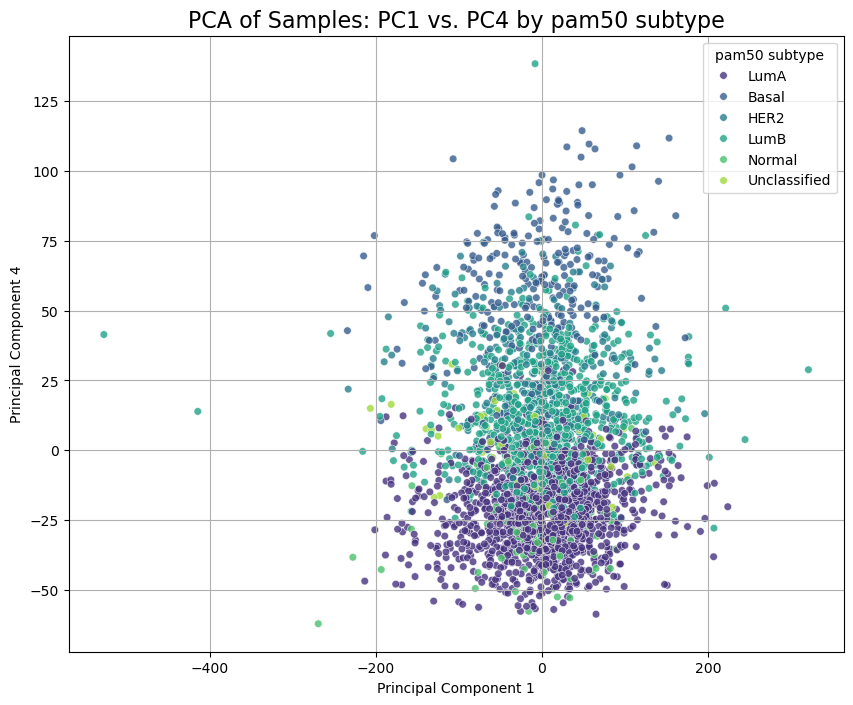

In [14]:
# Example graph usage 

# Example: Plot colored by clinical metadata by principal component of choice
plot_pca_by_metadata(pca_with_metadata, 'pam50 subtype',pc_x='PC1', pc_y='PC4')

### After Plotting:
### Interpreting the Principal Components: What are Loadings?

After reducing our data to 55 principal components, the next question is: what do these components actually *mean* biologically? That's where **loadings** come in.

Think of each principal component (e.g., PC1) as a summary of a major pattern in your data. This pattern is created by a specific mix of our original ~17,000 genes. Loadings are simply scores that tell us how much each individual gene contributes to that mix.

By looking at the genes with the highest loading values for a component, we can understand the biological process that component is capturing.

#### Therfore, we fit PCA with n=55 and extract the loading values, which quantify how much each gene contributes to each principal component.

In [15]:
# Extract loadings and transpose to get genes × PCs
loadings = pca.components_.T  # shape: (n_genes, 55)

# Creating DataFrame
loading_df = pd.DataFrame(loadings,
                          index=df_scaled.columns,  # genes
                          columns=[f'PC{i+1}' for i in range(55)])

# Preview the table
print("Shape of loading matrix:", loading_df.shape)
print("\nFirst 5 genes (rows):")
print(loading_df.head(1))

Shape of loading matrix: (16374, 55)

First 5 genes (rows):
           PC1       PC2      PC3       PC4       PC5       PC6     PC7  \
A1BG  0.003912  0.018571 -0.00207 -0.006296  0.002507  0.002742  0.0052   

           PC8       PC9     PC10  ...      PC46      PC47      PC48  \
A1BG -0.008667 -0.005686  0.00305  ...  0.002821  0.005102  0.004112   

          PC49      PC50    PC51      PC52      PC53      PC54      PC55  
A1BG -0.008769  0.018617  0.0121  0.001105 -0.006668 -0.008096 -0.001779  

[1 rows x 55 columns]


### Using the `get_top_loading_genes` Function

To make this process easy, we'll use the `get_top_loading_genes` function. It's designed to quickly pull out the most influential genes for any component you choose.

You can customise it using two main arguments:
* **`pc_name`**: The principal component you want to inspect (e.g., `'PC1'`, `'PC5'`).
* **`n`**: The number of top genes you want to see (it defaults to 10).

#### Example Usage

Here’s how you would use it to find the top 5 genes that contribute to **PC3**:

```python
print("Top 10 contributing genes for PC3:")
display(get_top_loading_genes(loading_df, 'PC3', n=5))

In [16]:
def get_top_loading_genes(loading_df, pc_name, n=10):
    """
    Identifies and returns a clean DataFrame of the top genes with the 
    highest absolute loading values for a given principal component.

    Args:
        loadings_df (pd.DataFrame): The DataFrame containing PCA loading values.
        pc_name (str): The name of the principal component column (e.g., 'PC1').
        n (int): The number of top genes to return.

    Returns:
        pd.DataFrame: A formatted DataFrame of the top n genes and their loading values.
    """
    # Work on a copy to avoid modifying the original loadings_df
    temp_df = loading_df.copy()
    
    # Calculate absolute loading values for the specified PC
    abs_loading_col = f'abs_{pc_name}'
    temp_df[abs_loading_col] = temp_df[pc_name].abs()

    # Sort by the absolute loading to get the strongest contributors
    top_genes_df = temp_df.sort_values(by=abs_loading_col, ascending=False).head(n)

    # Reset the index to make the gene IDs a column
    top_genes_df = top_genes_df.reset_index().rename(columns={'index': 'Gene'})

    # Return a clean table with only the essential columns
    return top_genes_df[['Gene', pc_name, abs_loading_col]]

In [23]:
# --- Function usage Example ---

# 'loading_df' is the DataFrame with all 55 loading values
print("Top 20 contributing genes for the selected PC:")
display(get_top_loading_genes(loading_df, 'PC4', n=20))

# storing the result in a dataframe:
top_pc_genes_df = get_top_loading_genes(loading_df, 'PC4', n=100)

Top 20 contributing genes for the selected PC:


,Gene,PC4,abs_PC4
0,CCNA2,0.025429,0.025429
1,KIF2C,0.025338,0.025338
2,CCNB2,0.025306,0.025306
3,AURKB,0.025300,0.025300
4,TPX2,0.025228,0.025228
5,CDCA8,0.025195,0.025195
6,MCM10,0.025189,0.025189
7,BUB1,0.025165,0.025165
8,UBE2C,0.025161,0.025161
9,AURKA,0.025116,0.025116


In [18]:
# Extracting the result in a csv file which will be used for comparison with the results of Differential expression analysis:
top_pc_genes_df.to_csv("top_pc_contributing_genes.csv", index=False)
print("file saved sucessfully")

file saved sucessfully


### Alternative Method: Global Gene Importance

Instead of looking at single components, we can find globally important genes by calculating their overall "magnitude" across all 55 PCs. This score identifies genes that are the most influential on the PCA model as a whole.

In [19]:
# Calculate the magnitude for each gene
loading_df['magnitude'] = loading_df.iloc[:, :55].pow(2).sum(axis=1).pow(0.5)

# Display the top 10 genes with the highest overall magnitude
print("Top 20 Genes by Overall Magnitude:")
display(loading_df.sort_values('magnitude', ascending=False).head(20)[['magnitude']])

Top 20 Genes by Overall Magnitude:


,magnitude
MT-ND6,0.103308
IFIT1,0.102855
HIST1H2BC,0.099751
AAMDC,0.098800
HIST1H4H,0.098772
NR4A1,0.098227
IFIT1B,0.098142
HIST2H2BE,0.098012
RIMKLA,0.097797
MTRNR2L10,0.096505


In [ ]:
# # Sort by magnitude and select the top n number of genes into a new DataFrame
# top_20_global_genes_df = loading_df.sort_values('magnitude', ascending=False).head(100)

# #  Reset the index to turn the gene names into a regular column
# top_20_global_genes_df = top_20_global_genes_df.reset_index()

# # Renameing the index column to 'Gene' for clarity
# top_20_global_genes_df = top_20_global_genes_df.rename(columns={'index': 'Gene'})

# # extracting only the gene name and magnitude columns for a clean output
# global_genes = top_20_global_genes_df[['Gene', 'magnitude']]


In [21]:
# # Save the final DataFrame to a CSV file
# global_genes.to_csv("top_20_global_genes.csv", index=False)

# print("Top 20 global genes saved to 'top_20_global_genes.csv'")
# display(global_genes)

In [22]:
# top_20_global_genes.to_csv("top_global_contributing_genes.csv", index=False)
# print("file saved sucessfully")